In [39]:
import os
import numpy as np
import tqdm
import tensorflow as tf
import keras
from keras.layers import Conv2D , Dense , Flatten , Rescaling , MaxPooling2D , GlobalAveragePooling2D , Activation , BatchNormalization , Dropout
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.utils import image_dataset_from_directory , img_to_array , load_img
import matplotlib.pyplot as plt
import seaborn as sns

We have imported all useful libraries at once

In [5]:
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


We have two gpu's so training will become around 10xfaster compared to using cpu

In [3]:
base_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_path , 'train')
val_dir = os.path.join(base_path , 'val')
test_dir = os.path.join(base_path , 'test')

In [4]:
print(f"Train : ")
for cls in os.listdir(train_dir):
    print(f"{cls} - {len(os.listdir(os.path.join(train_dir , cls)))}")
print('\n')

print(f"Validation : ")
for cls in os.listdir(val_dir):
    print(f"{cls} - {len(os.listdir(os.path.join(val_dir , cls)))}")
print('\n')

print(f"Test : ")
for cls in os.listdir(test_dir):
    print(f"{cls} - {len(os.listdir(os.path.join(test_dir , cls)))}")

Train : 
PNEUMONIA - 3875
NORMAL - 1341


Validation : 
PNEUMONIA - 8
NORMAL - 8


Test : 
PNEUMONIA - 390
NORMAL - 234


This is a kind of imbalanced classification. So it is better work using class weights otherwise our model will show bias towards PNEUMONIA class

/tmp/ipykernel_57/1045331933.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


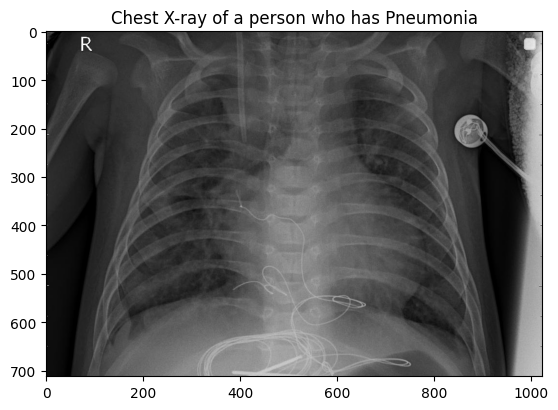

In [5]:
img_dir = os.path.join(os.path.join(train_dir , 'PNEUMONIA') , os.listdir(os.path.join(train_dir , 'PNEUMONIA'))[0])
img = load_img(img_dir)
img_arr = img_to_array(img)
plt.imshow(img_arr.astype('uint8'))
plt.title('Chest X-ray of a person who has Pneumonia')
plt.legend()

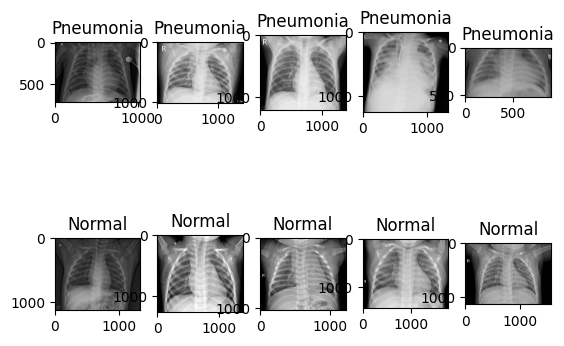

In [6]:
classes = ['PNEUMONIA' , 'NORMAL']
fig , axs = plt.subplots(2 , 5)
for j in range(2):
    cls_path = os.path.join(train_dir , classes[j])
    for i in range(5):
        img_path = os.path.join(cls_path , os.listdir(cls_path)[i])
        img = load_img(img_path)
        img_arr = img_to_array(img)
        axs[j , i].imshow(img_arr.astype('uint8'))
        axs[j , i].set_title(classes[j].capitalize())



<BarContainer object of 2 artists>

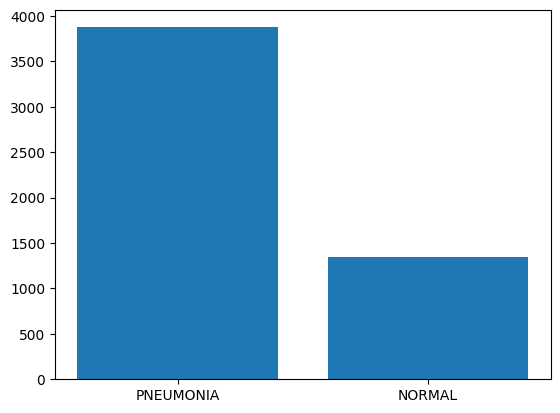

In [7]:
frequency = [len(os.listdir(os.path.join(train_dir , classes[0]))) , len(os.listdir(os.path.join(train_dir , classes[1])))]
plt.bar(classes , frequency)

In [8]:
train_ds , valid_ds = image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "binary",
    batch_size = 32,
    image_size = (224 , 224),
    color_mode = "rgb",
    seed = 42,
    validation_split = 0.2,
    subset = "both"
)

test_ds = image_dataset_from_directory(
    test_dir,
    labels = "inferred",
    label_mode = "binary",
    batch_size = 32,
    image_size = (224 ,224),
    color_mode = "rgb",
    shuffle = False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Using 1043 files for validation.


I0000 00:00:1780826212.784754      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780826212.790656      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 624 files belonging to 2 classes.


Since there are only 8 points in validation dataset we will completely ignore that and take 20% data from train dataser and mark it as valid_ds

So now we have train_ds , valid_ds and test_ds

In [12]:
print(f"Number of batches in train_ds : {len(train_ds)}")
print(f"Number of batches in valid_ds : {len(valid_ds)}")
print(f"Number of batches in test_ds : {len(test_ds)}")

Number of batches in train_ds : 131
Number of batches in valid_ds : 33
Number of batches in test_ds : 20


Here are the number of batches in all those three datasets and each batch consists of 32 images

In [9]:
for images , labels in train_ds.take(1):
    print(f"Shape of batch : {images.shape}")
    print(f"Shape of labels in a batch : {labels.shape}")

Shape of batch : (32, 224, 224, 3)
Shape of labels in a batch : (32, 1)


Later in this experiment we are uing transfer learning there model accepts image with 3 channels so even though it is gray-scale image we have made it into 3 channels and since we have used label_mode binary labels have shape (batch_size , 1)

In [10]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [24]:
inputs = keras.Input(shape=(224 , 224 , 3))
x = Rescaling(1.0/255)(inputs)

x = Conv2D(filters = 32 , kernel_size = 3 , activation="relu")(x)
x = MaxPooling2D(pool_size = 2)(x)

x = Conv2D(filters = 64 , kernel_size = 3 , activation="relu")(x)
x = MaxPooling2D(pool_size = 2)(x)

x = Conv2D(filters = 128 , kernel_size = 3 , activation = "relu")(x)

x = GlobalAveragePooling2D()(x)

x = Dense(32 , activation = "relu")(x)
outputs = Dense(1 , activation = "sigmoid")(x)

model = keras.models.Model(inputs = inputs , outputs = outputs)

In [27]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,409 (380.50 KB)

 Trainable params: 97,409 (380.50 KB)

 Non-trainable params: 0 (0.00 B)

This is our simple baseline model and we will compare our future models with this baseline model

In [28]:
callbacks = [
    keras.callbacks.ModelCheckpoint("simple_model.keras" , monitor = "val_accuracy" , save_best_only = True)
]
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy" , "AUC"]
)

history = model.fit(
    train_ds,
    epochs = 15,
    validation_data = valid_ds,
    callbacks = callbacks
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - AUC: 0.4842 - accuracy: 0.7078 - loss: 0.5997 - val_AUC: 0.6060 - val_accuracy: 0.7613 - val_loss: 0.5436
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - AUC: 0.6847 - accuracy: 0.7319 - loss: 0.5366 - val_AUC: 0.7049 - val_accuracy: 0.7613 - val_loss: 0.4986
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - AUC: 0.7397 - accuracy: 0.7323 - loss: 0.4913 - val_AUC: 0.7417 - val_accuracy: 0.7613 - val_loss: 0.4699
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - AUC: 0.7908 - accuracy: 0.7290 - loss: 0.4468 - val_AUC: 0.8535 - val_accuracy: 0.7613 - val_loss: 0.3732
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - AUC: 0.8711 - accuracy: 0.7364 - loss: 0.3764 - val_AUC: 0.8871 - val_accuracy: 0.8140 - val_loss: 0.3521
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - AUC: 0.9046 - accuracy: 0.8570 - loss: 0.3312 - val_AUC: 0.9114 - val_accuracy: 0.8696 - val_loss: 0.2943
Epoch 7/15
131/131 ━━━

In [29]:
history_dict = history.history
history_dict.keys()

dict_keys(['AUC', 'accuracy', 'loss', 'val_AUC', 'val_accuracy', 'val_loss'])

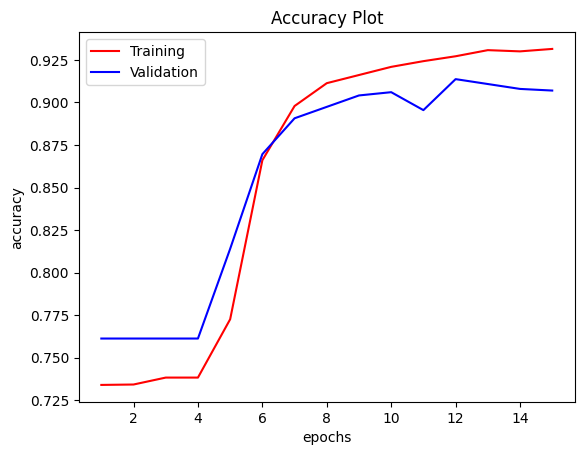

In [30]:
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['accuracy'] , c='r' , label = "Training")
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['val_accuracy'] , c='b' , label = "Validation")
plt.title("Accuracy Plot")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

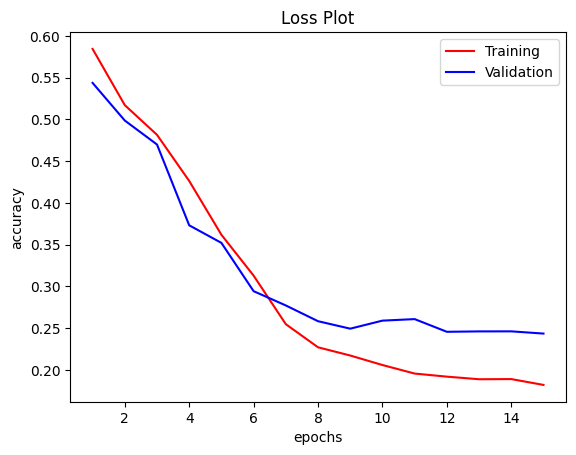

In [31]:
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['loss'] , c='r' , label = "Training")
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['val_loss'] , c='b' , label = "Validation")
plt.title("Loss Plot")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

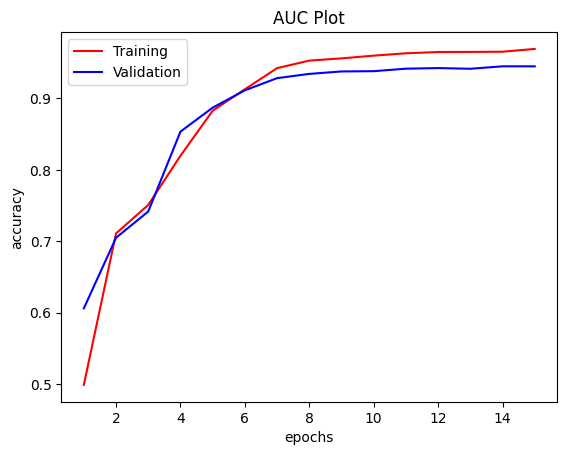

In [32]:
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['AUC'] , c='r' , label = "Training")
plt.plot(range(1 , len(history_dict['accuracy']) + 1) , history_dict['val_AUC'] , c='b' , label = "Validation")
plt.title("AUC Plot")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

In [34]:
model1 = keras.models.load_model("simple_model.keras")
print("Validation Loss , accuracy , AUC : " , model1.evaluate(valid_ds , verbose=0))
print("Test Loss , accuracy , AUC : " , model1.evaluate(test_ds , verbose=0))

Validation Loss , accuracy , AUC :  [0.2456815093755722, 0.9137104749679565, 0.9425106644630432]
Test Loss , accuracy , AUC :  [1.0705317258834839, 0.7099359035491943, 0.6842702031135559]


The possible reason for drop in test accuracy is change in distribution of data which is quite obvious in medical related data. Now let use confusion matrix to understand more about this baseline model

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = model1.predict(test_ds , verbose=0)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[ 67 167]
 [ 14 376]]
              precision    recall  f1-score   support

         0.0       0.83      0.29      0.43       234
         1.0       0.69      0.96      0.81       390

    accuracy                           0.71       624
   macro avg       0.76      0.63      0.62       624
weighted avg       0.74      0.71      0.66       624



our model is heavily biased towards pneumonia. It is actually predicting 96.4% of pneumonia as pneumonia which is quite good for this simple model. And the more serious error classifying pneumonia as normal is less we should decrease that error. Now let us find class weights

In [56]:
normal_samples = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_samples = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
total_samples = normal_samples + pneumonia_samples

normal_weight = total_samples / (2 * normal_samples)
pneumonia_weight = total_samples / (2 * pneumonia_samples)

class_weight = {0: normal_weight, 1: pneumonia_weight}

we will now use concept of transfer learning and use pre-trained model to improve our model.It will perform way better than this simple model

In [142]:
from keras.applications import DenseNet121
dense_net = DenseNet121(
    include_top = False,
    weights = "imagenet",
    input_shape = (224 , 224 , 3)
)

In [143]:
trainable_params = np.sum(
    [np.prod(v.shape) for v in dense_net.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in dense_net.non_trainable_weights]
)

print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Total params: {trainable_params + non_trainable_params:,}")

Trainable params: 6,953,856
Non-trainable params: 83,648
Total params: 7,037,504


There are total of 6,953,856 trainable paramerters and 83,648 non-trainable parameters.Now first make all trainable paramerters as false and then train our model by adding Dense layers

In [144]:
dense_net.trainable = False
trainable_params = np.sum(
    [np.prod(v.shape) for v in dense_net.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in dense_net.non_trainable_weights]
)

print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Total params: {trainable_params + non_trainable_params:,}")

Trainable params: 0.0
Non-trainable params: 7,037,504
Total params: 7,037,504.0


Now trainable parametrs are 0

In [145]:
inputs = keras.Input(shape=(224 , 224 , 3))
x = Rescaling(1/255.0)(inputs)

x = dense_net(x , training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(128 , activation = "relu")(x)
x = Dropout(0.3)(x)

x = Dense(64 , activation = "relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1 , activation = "sigmoid")(x)

model = keras.models.Model(inputs = inputs , outputs = outputs)

In [146]:
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_18 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177,025 (27.38 MB)

 Trainable params: 139,521 (545.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [147]:
callbacks = [
    keras.callbacks.ModelCheckpoint("pre_trained_model.keras" , monitor = "val_accuracy" , save_best_only=True)
]
model.compile(
    optimizer = Adam(1e-3),
    loss = "binary_crossentropy",
    metrics = ["accuracy" , "AUC"]
)

history = model.fit(
    train_ds,
    epochs = 10,
    validation_data = valid_ds,
    class_weight = class_weight,
    callbacks = callbacks
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 348ms/step - AUC: 0.8628 - accuracy: 0.7782 - loss: 0.4394 - val_AUC: 0.9867 - val_accuracy: 0.9089 - val_loss: 0.2398
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - AUC: 0.9830 - accuracy: 0.9288 - loss: 0.1645 - val_AUC: 0.9906 - val_accuracy: 0.9569 - val_loss: 0.1224
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - AUC: 0.9881 - accuracy: 0.9454 - loss: 0.1367 - val_AUC: 0.9912 - val_accuracy: 0.9415 - val_loss: 0.1603
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - AUC: 0.9887 - accuracy: 0.9512 - loss: 0.1223 - val_AUC: 0.9916 - val_accuracy: 0.9626 - val_loss: 0.1045
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - AUC: 0.9936 - accuracy: 0.9641 - loss: 0.0948 - val_AUC: 0.9929 - val_accuracy: 0.9453 - val_loss: 0.1603
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - AUC: 0.9947 - accuracy: 0.9638 - loss: 0.0902 - val_AUC: 0.9927 - val_accuracy: 0.9674 - val_loss: 0.0887
Epoch 7/10
131/131 ━━━

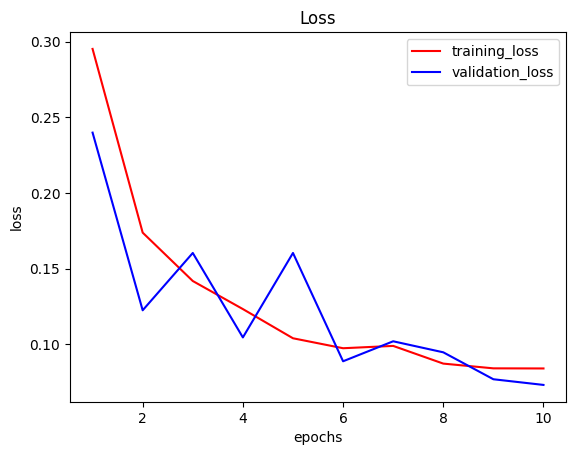

In [148]:
history_dict = history.history
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['loss'] , c = 'r' , label = 'training_loss')
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['val_loss'] , c = 'b' , label = 'validation_loss')
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

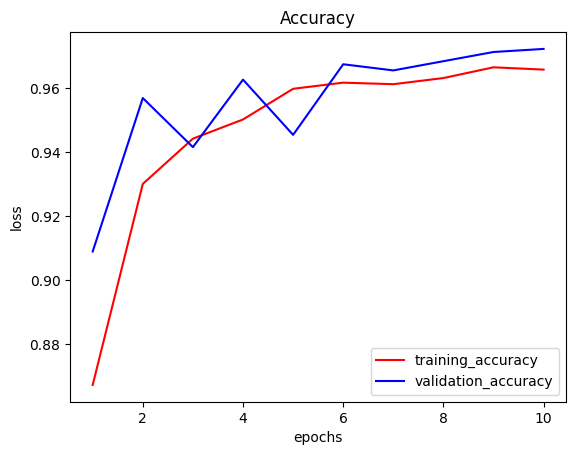

In [149]:
history_dict = history.history
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['accuracy'] , c = 'r' , label = 'training_accuracy')
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['val_accuracy'] , c = 'b' , label = 'validation_accuracy')
plt.title("Accuracy")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

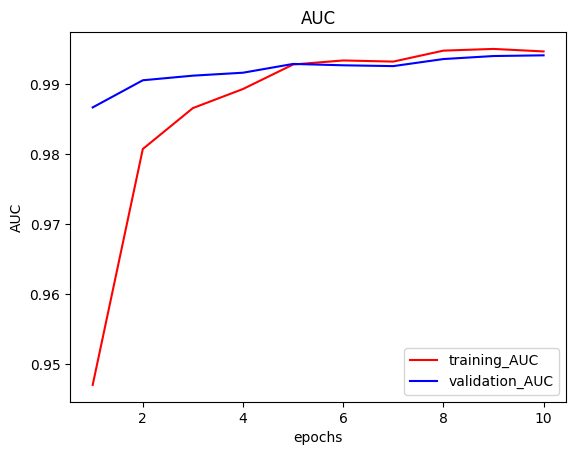

In [150]:
history_dict = history.history
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['AUC'] , c = 'r' , label = 'training_AUC')
plt.plot(range(1 , len(history_dict['loss']) + 1) , history_dict['val_AUC'] , c = 'b' , label = 'validation_AUC')
plt.title("AUC")
plt.xlabel("epochs")
plt.ylabel("AUC")
plt.legend()

In [168]:
pre_trained_model = keras.models.load_model("pre_trained_model.keras")
print("Validation Loss , accuracy , AUC : " , pre_trained_model.evaluate(valid_ds , verbose=0))
print("Test Loss , accuracy , AUC : " , pre_trained_model.evaluate(test_ds , verbose=0))

Validation Loss , accuracy , AUC :  [0.07311692833900452, 0.972195565700531, 0.9941326379776001]
Test Loss , accuracy , AUC :  [0.4903743863105774, 0.8573718070983887, 0.9471563696861267]


In [152]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = pre_trained_model.predict(test_ds , verbose=0)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[150  84]
 [  5 385]]
              precision    recall  f1-score   support

         0.0       0.97      0.64      0.77       234
         1.0       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



These results are much better than that original CNN we used. Now our model is misclassifying only 6 points as normal which are pneumonia originally. Now we will analyze predictions in test_ds

In [160]:
print("Unique true labels:", np.unique(y_true))
print("Prediction range:", min(y_pred), "-", max(y_pred))
print("Mean prediction:", np.array(y_pred).mean())

Unique true labels: [0. 1.]
Prediction range: 3.897083e-06 - 1.0
Mean prediction: 0.5993969


We can clearly see that our model's mean prediction is 0.0.5993 so it more biased to pneumonia and actually that is what we want because false-negative should be very less

Now we will fine tune the model since starting layers of dense_net identifies primitive features like edges we will not train them again. We will only concern about last 50 layers and make them trainable true. Now let us see how those layers look like

In [162]:
for layer in dense_net.layers[-50:]:
    print(layer.name, layer.trainable)

conv5_block10_0_relu False
conv5_block10_1_conv False
conv5_block10_1_bn False
conv5_block10_1_relu False
conv5_block10_2_conv False
conv5_block10_concat False
conv5_block11_0_bn False
conv5_block11_0_relu False
conv5_block11_1_conv False
conv5_block11_1_bn False
conv5_block11_1_relu False
conv5_block11_2_conv False
conv5_block11_concat False
conv5_block12_0_bn False
conv5_block12_0_relu False
conv5_block12_1_conv False
conv5_block12_1_bn False
conv5_block12_1_relu False
conv5_block12_2_conv False
conv5_block12_concat False
conv5_block13_0_bn False
conv5_block13_0_relu False
conv5_block13_1_conv False
conv5_block13_1_bn False
conv5_block13_1_relu False
conv5_block13_2_conv False
conv5_block13_concat False
conv5_block14_0_bn False
conv5_block14_0_relu False
conv5_block14_1_conv False
conv5_block14_1_bn False
conv5_block14_1_relu False
conv5_block14_2_conv False
conv5_block14_concat False
conv5_block15_0_bn False
conv5_block15_0_relu False
conv5_block15_1_conv False
conv5_block15_1_bn Fa

In [163]:
dense_net.trainable = True

for layer in dense_net.layers[:-50]:
    layer.trainable = False

In [164]:
for layer in dense_net.layers[-50:]:
    print(layer.name, layer.trainable)

conv5_block10_0_relu True
conv5_block10_1_conv True
conv5_block10_1_bn True
conv5_block10_1_relu True
conv5_block10_2_conv True
conv5_block10_concat True
conv5_block11_0_bn True
conv5_block11_0_relu True
conv5_block11_1_conv True
conv5_block11_1_bn True
conv5_block11_1_relu True
conv5_block11_2_conv True
conv5_block11_concat True
conv5_block12_0_bn True
conv5_block12_0_relu True
conv5_block12_1_conv True
conv5_block12_1_bn True
conv5_block12_1_relu True
conv5_block12_2_conv True
conv5_block12_concat True
conv5_block13_0_bn True
conv5_block13_0_relu True
conv5_block13_1_conv True
conv5_block13_1_bn True
conv5_block13_1_relu True
conv5_block13_2_conv True
conv5_block13_concat True
conv5_block14_0_bn True
conv5_block14_0_relu True
conv5_block14_1_conv True
conv5_block14_1_bn True
conv5_block14_1_relu True
conv5_block14_2_conv True
conv5_block14_concat True
conv5_block15_0_bn True
conv5_block15_0_relu True
conv5_block15_1_conv True
conv5_block15_1_bn True
conv5_block15_1_relu True
conv5_bl

In [165]:
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_18 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,456,069 (28.44 MB)

 Trainable params: 1,215,169 (4.64 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

 Optimizer params: 279,044 (1.06 MB)

Trainable parameters got increased to 1,215,169

In [166]:
from keras.callbacks import EarlyStopping

earlystopping = EarlyStopping(
    monitor = "val_accuracy",
    patience = 5,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    filepath = '/kaggle/working/best_model.keras',
    monitor = "val_accuracy",
    save_best_only = True
)

callbacks = [earlystopping , checkpoint]

In [167]:
model.compile(
    optimizer = Adam(1e-5),
    loss = "binary_crossentropy",
    metrics = ["accuracy" , "AUC"]
)

history = model.fit(
    train_ds,
    epochs = 30,
    validation_data = valid_ds,
    callbacks = callbacks,
    class_weight = class_weight
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 410ms/step - AUC: 0.9769 - accuracy: 0.9399 - loss: 0.3242 - val_AUC: 0.9933 - val_accuracy: 0.9655 - val_loss: 0.0909
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - AUC: 0.9916 - accuracy: 0.9612 - loss: 0.1186 - val_AUC: 0.9925 - val_accuracy: 0.9684 - val_loss: 0.1023
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - AUC: 0.9920 - accuracy: 0.9641 - loss: 0.1024 - val_AUC: 0.9927 - val_accuracy: 0.9674 - val_loss: 0.1013
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - AUC: 0.9960 - accuracy: 0.9681 - loss: 0.0748 - val_AUC: 0.9925 - val_accuracy: 0.9674 - val_loss: 0.0997
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - AUC: 0.9961 - accuracy: 0.9728 - loss: 0.0686 - val_AUC: 0.9929 - val_accuracy: 0.9693 - val_loss: 0.0914
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - AUC: 0.9963 - accuracy: 0.9739 - loss: 0.0720 - val_AUC: 0.9930 - val_accuracy: 0.9664 - val_loss: 0.0917
Epoch 7/30
131/131 ━━━

In [169]:
best_model = keras.models.load_model('/kaggle/working/best_model.keras')
print("Validation Loss , accuracy , AUC : " , best_model.evaluate(valid_ds , verbose=0))
print("Test Loss , accuracy , AUC : " , best_model.evaluate(test_ds , verbose=0))

Validation Loss , accuracy , AUC :  [0.07120098173618317, 0.9808245301246643, 0.9945449233055115]
Test Loss , accuracy , AUC :  [0.9987716674804688, 0.817307710647583, 0.8953539133071899]


In [171]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = best_model.predict(test_ds , verbose=0)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[123 111]
 [  3 387]]
              precision    recall  f1-score   support

         0.0       0.98      0.53      0.68       234
         1.0       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



In [173]:
print("Unique true labels:", np.unique(y_true))
print("Prediction range:", y_pred.min(), "-", y_pred.max())
print("Mean prediction:", y_pred.mean())

Unique true labels: [0. 1.]
Prediction range: 0 - 1
Mean prediction: 0.7980769230769231


Even though val_accuracy is better test_accuracy reduced it is actually common phenomenon but false-negative got reduced which is very essential. Actually here our main metric is false-negative than accuracy in that sense we are doing well